In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    learning_curve
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)



In [3]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [4]:
import mlflow
import mlflow.sklearn

In [5]:
# Load Breast Cancer dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset Shape:", X.shape)
print("\nFirst 5 rows:")
display(X.head())

print("\nClass Distribution:")
print(y.value_counts())

Dataset Shape: (569, 30)

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Class Distribution:
target
1    357
0    212
Name: count, dtype: int64


In [6]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [7]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Probability predictions for ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]

In [8]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Model Evaluation Metrics")
print("-------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

Model Evaluation Metrics
-------------------------
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1 Score  : 0.9861
ROC-AUC   : 0.9954


In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Confusion Matrix:
[[41  1]
 [ 1 71]]


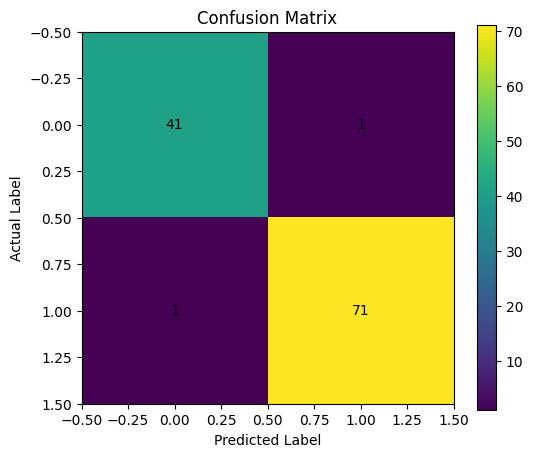

In [10]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

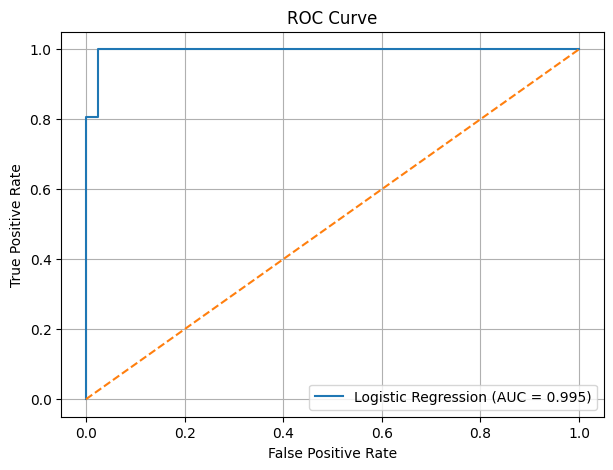

In [11]:
# Calculate false positive rate and true positive rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [12]:
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("5-Fold Cross-Validation Scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

5-Fold Cross-Validation Scores:
[0.98245614 0.98245614 0.97368421 0.97368421 0.99115044]

Mean CV Accuracy: 0.9806862288464524
Standard Deviation: 0.006539441283506109


In [13]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified_scores = cross_val_score(
    model,
    X,
    y,
    cv=skf,
    scoring="roc_auc"
)

print("Stratified 5-Fold ROC-AUC Scores:")
print(stratified_scores)

print("\nMean ROC-AUC:", stratified_scores.mean())
print("Standard Deviation:", stratified_scores.std())

Stratified 5-Fold ROC-AUC Scores:
[0.9950868  0.99770717 0.98511905 1.         0.99865862]

Mean ROC-AUC: 0.9953143278274297
Standard Deviation: 0.005345297368904418


In [14]:
metrics = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1 Score": "f1",
    "ROC-AUC": "roc_auc"
}

results = {}

for metric_name, scoring_method in metrics.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=skf,
        scoring=scoring_method
    )

    results[metric_name] = scores.mean()

results_df = pd.DataFrame(
    list(results.items()),
    columns=["Metric", "Mean CV Score"]
)

display(results_df)

,Metric,Mean CV Score
0,Accuracy,0.973669
1,Precision,0.968254
2,Recall,0.991588
3,F1 Score,0.979434
4,ROC-AUC,0.995314


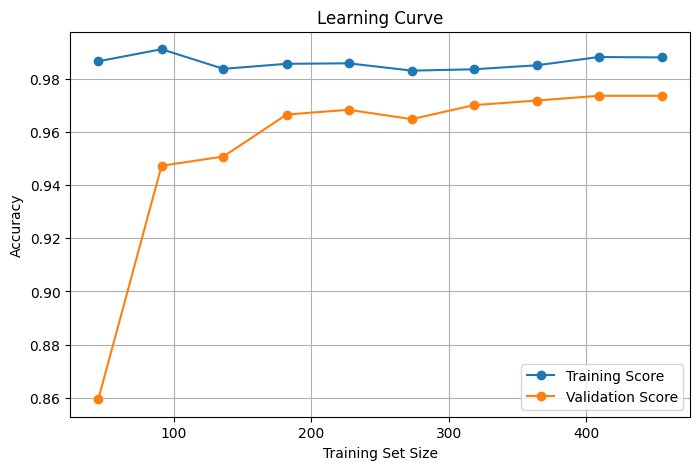

In [15]:
train_sizes, train_scores, validation_scores = learning_curve(
    model,
    X,
    y,
    cv=skf,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Score"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation Score"
)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid()

plt.show()

In [16]:
# Start MLflow experiment
mlflow.set_experiment("W4D1_Model_Evaluation")

with mlflow.start_run():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # Log parameters
    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("test_size", 0.20)
    mlflow.log_param("cv_folds", 5)

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", auc)

    # Log model
    mlflow.sklearn.log_model(model, "logistic_regression_model")

    print("MLflow run completed successfully.")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

2026/08/25 13:22:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/25 13:22:40 INFO mlflow.store.db.utils: Updating database tables
2026/08/25 13:22:45 INFO mlflow.tracking.fluent: Experiment with name 'W4D1_Model_Evaluation' does not exist. Creating a new experiment.
2026/08/25 13:22:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow run completed successfully.
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861
ROC-AUC  : 0.9954


In [17]:
summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Test Score": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

display(summary)

,Metric,Test Score
0,Accuracy,0.982456
1,Precision,0.986111
2,Recall,0.986111
3,F1 Score,0.986111
4,ROC-AUC,0.995370
